In [50]:
!pip install gdown pandas openpyxl transformers torch tqdm

# Asgmt1: Explore Your Dataset

## Load your data (for public sharing)

In [1]:
import gdown
import pandas as pd

# Upload the data file to your Google Drive, and turn on the link sharing
# Replace 'YOUR_FILE_ID' with the actual file ID from your public Google Drive link e.g., "https://drive.google.com/file/d/YOUR_FILE_ID/view?usp=sharing"
# Example data is from https://www.kaggle.com/datasets/carolzhangdc/imdb-5000-movie-dataset/data
file_id = '10qDeoDQe4UifB-jECpquJ0lrg7UZc0O2'

# Name for the downloaded file in Colab
output_filename = 'val.xlsx'

gdown.download(id=file_id, output=output_filename, quiet=False)

print(f"File '{output_filename}' downloaded successfully!")

# Now you can load it with pandas
df_raw = pd.read_excel(output_filename)
display(df_raw.head())

Downloading...
From: https://drive.google.com/uc?id=10qDeoDQe4UifB-jECpquJ0lrg7UZc0O2
To: /content/val.xlsx
100%|██████████| 1.17M/1.17M [00:00<00:00, 84.1MB/s]


File 'val.xlsx' downloaded successfully!


,Unnamed: 0,연령,성별,상황키워드,신체질환,감정_대분류,감정_소분류,사람문장1,시스템문장1,사람문장2,시스템문장2,사람문장3,시스템문장3
0,1,청년,남성,"진로,취업,직장",해당없음,불안,두려운,이번 프로젝트에서 발표를 하는데 내가 실수하는 바람에 우리 팀이 감점을 받았어. 너...,실수하시다니 정말 미안한 마음이 크겠어요.,내 능력이 부족한 거 같은데 그만 다녀야 될거같아.,능력을 올리려면 어떤 방법이 있을까요?,퇴근 후 여가에 회사 일을 더 열심히 해서 피해가 가지 않도록 해야겠어.,꼭 좋은 결과 있길 바라요.
1,2,청년,남성,"진로,취업,직장",해당없음,불안,두려운,회사에서 중요한 프로젝트를 혼자 하게 됐는데 솔직히 두렵고 무서워.,큰 프로젝트를 혼자 하셔서 고민이 많겠네요.,나에게 너무 크게 느껴지는 중요한 프로젝트라 버거운 느낌이 들어.,프로젝트를 잘하시기 위해서 어떤 걸 할 수 있나요?,동료 직원에게 도움을 요청해서 같이 해결해야겠어.,동료 직원에게 도움을 요청하기로 하셨군요.
2,3,청년,남성,"진로,취업,직장",해당없음,불안,두려운,상사가 너무 무섭게 생겨서 친해지는 게 너무 두려워.,직장 상사가 무섭게 생기셔서 친해지는 게 어렵군요.,무섭게 생겼는데도 업무를 보려면 친해져야 할 것 같단말이야.,상사분과 친해질 수 있는 방법은 무엇이 있을까요?,먼저 다가가서 말을 걸어볼게.,직장 상사와 친해지시면 좋겠네요.
3,4,청년,남성,"진로,취업,직장",해당없음,불안,두려운,이번에 힘들게 들어간 첫 직장이거든. 첫 직장이라서 그런지 너무 긴장된다.,첫 직장이라서 정말 떨리시고 긴장되실 것 같아요.,첫 직장이어서 잘 적응을 할 수 있을지 모르겠어.,잘 적응 하시려면 무엇을 할 수 있을까요?,직장 동료와 상사들이랑 친하게 지내야겠어.,직장에 잘 적응하시길 바라요.
4,5,청년,남성,"진로,취업,직장",해당없음,불안,두려운,직장에서 동료들이랑 관계가 안 좋아질까 봐 걱정돼.,직장 사람들 관계에 대해서 고민이시군요.,내가 낯가림이 심해서 친해질 수 있을지 모르겠어.,직장 사람들과 친해지려면 무슨 방법이 있을까요?,서로 같은 취미를 공유하고 얘기를 나누다 보면 친해질 수 있을 거 같아.,직장 사람들과 좋은 관계를 가지시길 응원해요.


In [2]:
import gdown
import pandas as pd
from transformers import pipeline
from tqdm import tqdm

# tqdm을 pandas의 apply에 연동 (progress_apply 사용 가능)
tqdm.pandas()

# ==========================================
# 1. 구글 드라이브에서 데이터 다운로드 및 로드
# ==========================================
print("구글 드라이브에서 'val.xlsx' 다운로드 중...")
file_id = '10qDeoDQe4UifB-jECpquJ0lrg7UZc0O2'
output_filename = 'val.xlsx'

# quiet=False로 다운로드 진행 상황 표시
gdown.download(id=file_id, output=output_filename, quiet=False)
print(f"\n파일 '{output_filename}' 다운로드 완료!\n")

# 데이터 로드 및 상위 5개 확인
df_raw = pd.read_excel(output_filename)
print("데이터 정상 로드 완료. 상위 5개 행:")
display(df_raw.head())

# ==========================================
# 2. 감성 분석 모델 로드 및 데이터 전처리
# ==========================================
model_name = "MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7"
print(f"\n모델 로딩 중: {model_name}...")
classifier = pipeline("zero-shot-classification", model=model_name)

print("\n텍스트 병합 중...")
# 결측치(NaN)는 빈 문자열로 처리하고, 사람문장 1, 2, 3을 띄어쓰기로 이어붙입니다.
combined_sentences = (
    df_raw['사람문장1'].fillna('') + " " +
    df_raw['사람문장2'].fillna('') + " " +
    df_raw['사람문장3'].fillna('')
).str.strip()

# ==========================================
# 3. 감성 분석 수행 (-1 ~ 1 점수화)
# ==========================================
candidate_labels = ["긍정", "부정", "중립"]

def get_sentiment_score(text):
    if not text or str(text).strip() == "":
        return 0.0

    # zero-shot 분류 (truncation=True 옵션으로 긴 문장 처리)
    result = classifier(str(text), candidate_labels, truncation=True)
    scores_dict = dict(zip(result['labels'], result['scores']))

    # 긍정 확률에서 부정 확률을 빼서 -1(부정) ~ 1(긍정) 사이 점수 도출
    return scores_dict.get("긍정", 0.0) - scores_dict.get("부정", 0.0)

print(f"\n총 {len(df_raw)}개 데이터에 대한 감성 분석 시작 (진행률 바가 표시됩니다)...")
# progress_apply를 사용하여 진행률 표시
sentiment_scores = combined_sentences.progress_apply(get_sentiment_score)

# ==========================================
# 4. 결과 병합 및 엑셀 저장
# ==========================================
df_result = pd.DataFrame({
    '사람문장_통합': combined_sentences,
    '추론_감성_점수': sentiment_scores
})

print("\n분석 결과를 기존 df_raw에 concat하여 업데이트 합니다...")
# 기존 df_raw 변수에 분석 결과(통합문장, 감성점수)를 가로(axis=1)로 병합하여 덮어쓰기
df_raw = pd.concat([df_raw, df_result], axis=1)

output_path = "result.xlsx"
# 덮어쓴 df_raw를 엑셀로 저장
df_raw.to_excel(output_path, index=False)
print(f"분석 및 병합 완료! 최종 결과가 '{output_path}'에 무사히 저장되었습니다.")

# 최종 데이터 확인용 출력
display(df_raw[['사람문장_통합', '추론_감성_점수']].head(10))

구글 드라이브에서 'val.xlsx' 다운로드 중...


Downloading...
From: https://drive.google.com/uc?id=10qDeoDQe4UifB-jECpquJ0lrg7UZc0O2
To: /content/val.xlsx
100%|██████████| 1.17M/1.17M [00:00<00:00, 166MB/s]



파일 'val.xlsx' 다운로드 완료!

데이터 정상 로드 완료. 상위 5개 행:


,Unnamed: 0,연령,성별,상황키워드,신체질환,감정_대분류,감정_소분류,사람문장1,시스템문장1,사람문장2,시스템문장2,사람문장3,시스템문장3
0,1,청년,남성,"진로,취업,직장",해당없음,불안,두려운,이번 프로젝트에서 발표를 하는데 내가 실수하는 바람에 우리 팀이 감점을 받았어. 너...,실수하시다니 정말 미안한 마음이 크겠어요.,내 능력이 부족한 거 같은데 그만 다녀야 될거같아.,능력을 올리려면 어떤 방법이 있을까요?,퇴근 후 여가에 회사 일을 더 열심히 해서 피해가 가지 않도록 해야겠어.,꼭 좋은 결과 있길 바라요.
1,2,청년,남성,"진로,취업,직장",해당없음,불안,두려운,회사에서 중요한 프로젝트를 혼자 하게 됐는데 솔직히 두렵고 무서워.,큰 프로젝트를 혼자 하셔서 고민이 많겠네요.,나에게 너무 크게 느껴지는 중요한 프로젝트라 버거운 느낌이 들어.,프로젝트를 잘하시기 위해서 어떤 걸 할 수 있나요?,동료 직원에게 도움을 요청해서 같이 해결해야겠어.,동료 직원에게 도움을 요청하기로 하셨군요.
2,3,청년,남성,"진로,취업,직장",해당없음,불안,두려운,상사가 너무 무섭게 생겨서 친해지는 게 너무 두려워.,직장 상사가 무섭게 생기셔서 친해지는 게 어렵군요.,무섭게 생겼는데도 업무를 보려면 친해져야 할 것 같단말이야.,상사분과 친해질 수 있는 방법은 무엇이 있을까요?,먼저 다가가서 말을 걸어볼게.,직장 상사와 친해지시면 좋겠네요.
3,4,청년,남성,"진로,취업,직장",해당없음,불안,두려운,이번에 힘들게 들어간 첫 직장이거든. 첫 직장이라서 그런지 너무 긴장된다.,첫 직장이라서 정말 떨리시고 긴장되실 것 같아요.,첫 직장이어서 잘 적응을 할 수 있을지 모르겠어.,잘 적응 하시려면 무엇을 할 수 있을까요?,직장 동료와 상사들이랑 친하게 지내야겠어.,직장에 잘 적응하시길 바라요.
4,5,청년,남성,"진로,취업,직장",해당없음,불안,두려운,직장에서 동료들이랑 관계가 안 좋아질까 봐 걱정돼.,직장 사람들 관계에 대해서 고민이시군요.,내가 낯가림이 심해서 친해질 수 있을지 모르겠어.,직장 사람들과 친해지려면 무슨 방법이 있을까요?,서로 같은 취미를 공유하고 얘기를 나누다 보면 친해질 수 있을 거 같아.,직장 사람들과 좋은 관계를 가지시길 응원해요.



모델 로딩 중: MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7...


...

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]


텍스트 병합 중...

총 6641개 데이터에 대한 감성 분석 시작 (진행률 바가 표시됩니다)...


100%|██████████| 6641/6641 [08:50<00:00, 12.53it/s]



분석 결과를 기존 df_raw에 concat하여 업데이트 합니다...
분석 및 병합 완료! 최종 결과가 'val_sentiment_results_final.xlsx'에 무사히 저장되었습니다.


,사람문장_통합,추론_감성_점수
0,이번 프로젝트에서 발표를 하는데 내가 실수하는 바람에 우리 팀이 감점을 받았어. 너...,-0.682257
1,회사에서 중요한 프로젝트를 혼자 하게 됐는데 솔직히 두렵고 무서워. 나에게 너무 크...,-0.688704
2,상사가 너무 무섭게 생겨서 친해지는 게 너무 두려워. 무섭게 생겼는데도 업무를 보려...,-0.586495
3,이번에 힘들게 들어간 첫 직장이거든. 첫 직장이라서 그런지 너무 긴장된다. 첫 직장...,-0.461388
4,직장에서 동료들이랑 관계가 안 좋아질까 봐 걱정돼. 내가 낯가림이 심해서 친해질 수...,-0.462224
5,내가 평소에 말이 좀 험한 편인데 무서운 팀장님 앞에서 말실수할까 봐 걱정이야. 팀...,-0.173012
6,내 직급이 낮아서 그런지 회의 시간에 내 의견을 무시하는 경향이 있어서 의견을 제시...,-0.562037
7,부장님께 보고서를 올렸는데 혹시 실수한 거 지적당할까 봐 걱정이야. 내가 한 실수 ...,-0.296375
8,내일 회사 면접을 보러 가는데 내가 틱 증상이 있어서 불안해. 떨어질까 봐 걱정이야...,-0.368708
9,친구랑 같이 백수였는데 내가 이번에 취업을 하는 바람에 그 친구와 멀어질까 봐 걱정...,0.006245


In [5]:
from google.colab import files

files.download(output_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


## 1. Get variable statistics

Explore the structure of your dataset:

### 1.1 List your variables
- Use `df_raw.columns` or `df_raw.info()` to list all variables and their data types.
- Briefly describe what each variable represents (1 line each).

### 1.2 Count unique values
For categorical/text variables, use `nunique()` to count unique entries (e.g., how many unique units, categories, or labels are in the data?).

### 1.3 Descriptive statistics for numeric variables
Use `df_raw.describe()` to report mean, std, min, max, and quartiles.

### 1.4 Missing values
Use `df_raw.isnull().sum()` to check missingness per variable.

### 1.5 Short interpretation (2–3 sentences)
Summarize what stands out: range, skewness, or variables with heavy missingness that may affect later analyses.


In [6]:
# 1.1 List variables and types
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6641 entries, 0 to 6640
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  6641 non-null   int64  
 1   연령          6641 non-null   object 
 2   성별          6641 non-null   object 
 3   상황키워드       6641 non-null   object 
 4   신체질환        6641 non-null   object 
 5   감정_대분류      6641 non-null   object 
 6   감정_소분류      6641 non-null   object 
 7   사람문장1       6641 non-null   object 
 8   시스템문장1      6641 non-null   object 
 9   사람문장2       6641 non-null   object 
 10  시스템문장2      6641 non-null   object 
 11  사람문장3       4686 non-null   object 
 12  시스템문장3      4686 non-null   object 
 13  사람문장_통합     6641 non-null   object 
 14  추론_감성_점수    6641 non-null   float64
dtypes: float64(1), int64(1), object(13)
memory usage: 778.4+ KB


In [7]:
# 1.2 Count unique values for categorical/text variables
cat_cols = df_raw.select_dtypes(include='object').columns
df_raw[cat_cols].nunique()

,0
연령,4
성별,2
상황키워드,12
신체질환,3
감정_대분류,6
감정_소분류,58
사람문장1,6641
시스템문장1,6559
사람문장2,6584
시스템문장2,6549


In [8]:
# 1.3 Descriptive statistics for numeric variables
df_raw.describe()


,Unnamed: 0,추론_감성_점수
count,6641.000000,6641.000000
mean,3321.000000,-0.200452
std,1917.235901,0.542961
min,1.000000,-0.959121
25%,1661.000000,-0.603939
50%,3321.000000,-0.381645
75%,4981.000000,0.037776
max,6641.000000,0.986820


In [9]:
# 1.4 Missing values per variable
df_raw.isnull().sum().sort_values(ascending=False)


,0
시스템문장3,1955
사람문장3,1955
Unnamed: 0,0
상황키워드,0
신체질환,0
연령,0
성별,0
감정_소분류,0
감정_대분류,0
사람문장1,0


### 1.5 Short Interpretation:

The dataset covers ~5000 movies spanning a wide range of release years, with `imdb_score` roughly normally distributed but `budget` and `gross` strongly right-skewed (a few blockbusters pull the mean far above the median). Variables like `gross`, `budget`, and `content_rating` have substantial missing values, so any analysis using them should drop or impute carefully. Categorical variables such as `director_name` and `actor_1_name` have thousands of unique values, meaning most directors/actors appear in only one or two films.


In [10]:
df_raw.rename(columns={'추론_감성_점수': 'sentiment_data'}, inplace=True)


## 2. Check distributions, z-score transform, visualize (1pt)

Pick one numeric variable of interest from your dataset (e.g., a rating, score, count, or measurement).

### 2.1 Report basic statistics
Report the mean, min, and max of your chosen variable.

### 2.2 Plot the raw distribution
Visualize the distribution using a histogram (e.g., `df_raw['var'].plot(kind='hist')` or `sns.histplot(df_raw['var'])`).

### 2.3 Z-score transform
Create a new column `zscore` with the standardized values of your variable.
Hint: `df_raw['zscore'] = df_raw['var'].apply(lambda x: (x - df_raw['var'].mean()) / df_raw['var'].std())`

### 2.4 Plot the z-score distribution
Visualize the standardized distribution with `sns.histplot(df_raw['zscore'], kde=False)`.

### 2.5 Short interpretation (2–3 sentences)
Comment on the shape of the distribution (symmetric, skewed, bimodal, heavy-tailed?) and what changed after standardization. Note any outliers (|z| > 3) and whether they look like data errors or genuine extreme cases.


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# 2.1 Basic statistics for imdb_score
print(f"Mean: {df_raw['sentiment_data'].mean():.2f}")
print(f"Min:  {df_raw['sentiment_data'].min():.2f}")
print(f"Max:  {df_raw['sentiment_data'].max():.2f}")


Mean: -0.20
Min:  -0.96
Max:  0.99


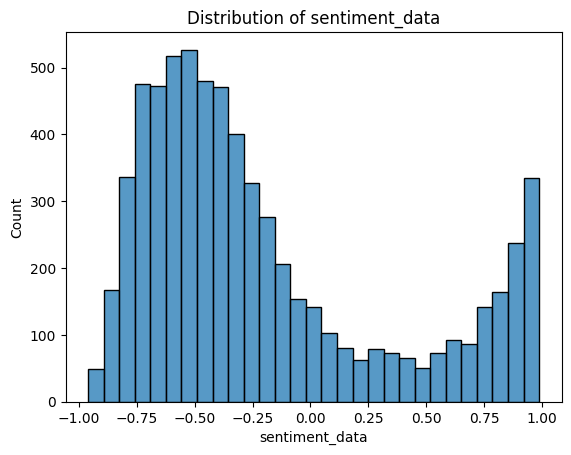

In [12]:
# 2.2 Plot the raw distribution
sns.histplot(df_raw['sentiment_data'], kde=False)
plt.title('Distribution of sentiment_data')
plt.show()


In [13]:
# 2.3 Z-score transform
df_raw['zscore'] = df_raw['sentiment_data'].apply(
    lambda x: (x - df_raw['sentiment_data'].mean()) / df_raw['sentiment_data'].std()
)
df_raw[['sentiment_data', 'zscore']].head()


,sentiment_data,zscore
0,-0.682257,-0.887366
1,-0.688704,-0.899239
2,-0.586495,-0.710995
3,-0.461388,-0.480579
4,-0.462224,-0.482119


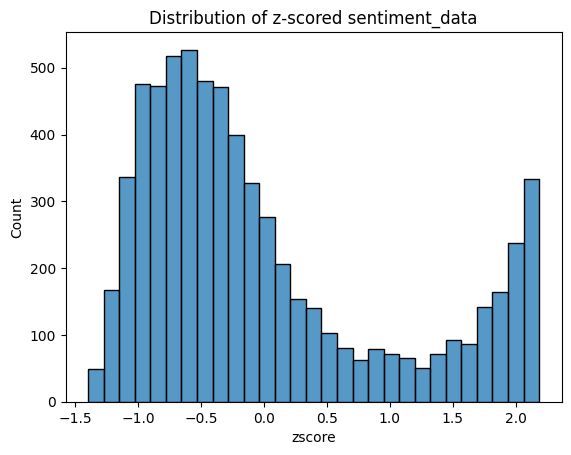

In [14]:
# 2.4 Plot the z-score distribution
sns.histplot(df_raw['zscore'], kde=False)
plt.title('Distribution of z-scored sentiment_data')
plt.show()


### 2.5 Interpretation

The raw IMDB scores are roughly bell-shaped but slightly left-skewed, with most films clustered between 6 and 8 and a thin tail of poorly-rated movies below 4. After z-scoring, the distribution keeps its shape but is recentered at 0 with std 1, making outliers easier to spot — films with z < -3 are exceptionally low-rated, and z > 3 marks the rare highly acclaimed titles.


## 3. Grouping

Pick one categorical variable (a grouping variable) and one numeric variable (an outcome) from your dataset.

### 3.1 Frequency of categories
Count how often each category appears using `value_counts()`, and visualize with `.value_counts().plot(kind='bar')`.
Report which category is the most and least frequent.

### 3.2 Group-level summary
Use `groupby()` to compute a summary statistic (mean, median, count, etc.) of your numeric variable for each category.
Hint: `df_raw.groupby('category_var')['numeric_var'].mean().sort_values(ascending=False)`

### 3.3 Visualize group differences
Plot the group-level summary as a bar chart so differences across categories are easy to compare.

### 3.4 Short interpretation (2–3 sentences)
Which category has the highest/lowest values of your outcome? Are the differences large or small relative to the overall spread you observed in section 2? Note any categories with very few observations — their group means may be unreliable.


In [15]:
df_raw.rename(columns={'성별': 'sex', '감정_대분류': 'Sentiment'}, inplace=True)

In [16]:
df_raw['Sentiment'].unique()

array(['불안', '슬픔', '당황', '기쁨', '분노', '상처'], dtype=object)

In [18]:
# Genres are pipe-separated, so explode into one row per (movie, genre)
# df_raw['Sentiment'] = df_raw['Sentiment'].map({'불안': 'anxiety', '슬픔': 'sadness', '기쁨':'happiness', '분노':'anger', '상처':'hurt','당황':'embarrassment'})
df_sentiment = df_raw.assign(sentiment=df_raw['Sentiment']).explode('Sentiment')
df_sentiment


,Unnamed: 0,연령,sex,상황키워드,신체질환,Sentiment,감정_소분류,사람문장1,시스템문장1,사람문장2,시스템문장2,사람문장3,시스템문장3,사람문장_통합,sentiment_data,zscore,sentiment
0,1,청년,남성,"진로,취업,직장",해당없음,anxiety,두려운,이번 프로젝트에서 발표를 하는데 내가 실수하는 바람에 우리 팀이 감점을 받았어. 너...,실수하시다니 정말 미안한 마음이 크겠어요.,내 능력이 부족한 거 같은데 그만 다녀야 될거같아.,능력을 올리려면 어떤 방법이 있을까요?,퇴근 후 여가에 회사 일을 더 열심히 해서 피해가 가지 않도록 해야겠어.,꼭 좋은 결과 있길 바라요.,이번 프로젝트에서 발표를 하는데 내가 실수하는 바람에 우리 팀이 감점을 받았어. 너...,-0.682257,-0.887366,anxiety
1,2,청년,남성,"진로,취업,직장",해당없음,anxiety,두려운,회사에서 중요한 프로젝트를 혼자 하게 됐는데 솔직히 두렵고 무서워.,큰 프로젝트를 혼자 하셔서 고민이 많겠네요.,나에게 너무 크게 느껴지는 중요한 프로젝트라 버거운 느낌이 들어.,프로젝트를 잘하시기 위해서 어떤 걸 할 수 있나요?,동료 직원에게 도움을 요청해서 같이 해결해야겠어.,동료 직원에게 도움을 요청하기로 하셨군요.,회사에서 중요한 프로젝트를 혼자 하게 됐는데 솔직히 두렵고 무서워. 나에게 너무 크...,-0.688704,-0.899239,anxiety
2,3,청년,남성,"진로,취업,직장",해당없음,anxiety,두려운,상사가 너무 무섭게 생겨서 친해지는 게 너무 두려워.,직장 상사가 무섭게 생기셔서 친해지는 게 어렵군요.,무섭게 생겼는데도 업무를 보려면 친해져야 할 것 같단말이야.,상사분과 친해질 수 있는 방법은 무엇이 있을까요?,먼저 다가가서 말을 걸어볼게.,직장 상사와 친해지시면 좋겠네요.,상사가 너무 무섭게 생겨서 친해지는 게 너무 두려워. 무섭게 생겼는데도 업무를 보려...,-0.586495,-0.710995,anxiety
3,4,청년,남성,"진로,취업,직장",해당없음,anxiety,두려운,이번에 힘들게 들어간 첫 직장이거든. 첫 직장이라서 그런지 너무 긴장된다.,첫 직장이라서 정말 떨리시고 긴장되실 것 같아요.,첫 직장이어서 잘 적응을 할 수 있을지 모르겠어.,잘 적응 하시려면 무엇을 할 수 있을까요?,직장 동료와 상사들이랑 친하게 지내야겠어.,직장에 잘 적응하시길 바라요.,이번에 힘들게 들어간 첫 직장이거든. 첫 직장이라서 그런지 너무 긴장된다. 첫 직장...,-0.461388,-0.480579,anxiety
4,5,청년,남성,"진로,취업,직장",해당없음,anxiety,두려운,직장에서 동료들이랑 관계가 안 좋아질까 봐 걱정돼.,직장 사람들 관계에 대해서 고민이시군요.,내가 낯가림이 심해서 친해질 수 있을지 모르겠어.,직장 사람들과 친해지려면 무슨 방법이 있을까요?,서로 같은 취미를 공유하고 얘기를 나누다 보면 친해질 수 있을 거 같아.,직장 사람들과 좋은 관계를 가지시길 응원해요.,직장에서 동료들이랑 관계가 안 좋아질까 봐 걱정돼. 내가 낯가림이 심해서 친해질 수...,-0.462224,-0.482119,anxiety
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6636,6637,청년,여성,"연애,결혼,출산",해당없음,embarrassment,열등감,나랑 비슷한 시기에 결혼하는 친구는 시댁에서 집을 해줘서 너무 부러워. 우리는 대출...,같은 시기에 결혼하는 친구들끼리 상황이 다르다 보니 마음이 좋지 않으시겠어요.,우리만 뒤처지는 것 같고. 그래도 열심히 살다 보면 우리도 집을 살 수 있겠지?,우리 부부만 뒤처지는 것 같아 속상하지만 열심히 살다 보면 집을 살 수 있다고 믿으...,NaN,NaN,나랑 비슷한 시기에 결혼하는 친구는 시댁에서 집을 해줘서 너무 부러워. 우리는 대출...,-0.174043,0.048640,embarrassment
6637,6638,청년,여성,"연애,결혼,출산",해당없음,embarrassment,열등감,친구 한 명이 결혼해서 아이를 가졌는데 너무 행복해 보이더라. 기분이 좋지만은 않아.,기분이 좋지 않으신 이유를 알고 계시나요?,나도 결혼했지만 아이도 생기지 않고 그 정도로 행복하지 않거든. 친구보다 못사는 것...,친구분과 비교하게 되어 기분이 좋지 않으셨군요. 어떻게 하면 기분이 풀릴 수 있을까요?,NaN,NaN,친구 한 명이 결혼해서 아이를 가졌는데 너무 행복해 보이더라. 기분이 좋지만은 않아...,-0.493816,-0.540304,embarrassment
6638,6639,청년,여성,"연애,결혼,출산",해당없음,embarrassment,열등감,남들은 결혼 전에 일억을 모았다는데 난 뭐를 한 것인지 모르겠어. 자괴감만 드네.,돈을 모으는 것으로 자괴감이 드시는군요.,요새 집값이 너무 올라서 한숨만 나와.,집값이 올라 한숨만 나오시는군요.,NaN,NaN,남들은 결혼 전에 일억을 모았다는데 난 뭐를 한 것인지 모르겠어. 자괴감만 드네. ...,-0.708561,-0.935810,embarrassment
6639,6640,청년,여성,"연애,결혼,출산",해당없음,embarrassment,열등감,나보다 결혼을 먼저 한 친구가 부러워. 그 친구 남편은 직장도 내 남편보다 좋고 키...,먼저 결혼한 친구가 부럽군요.,맞아. 그 친구와 비교하게 되니 자존감이 낮아지는 기분이야.,비교로 자존감이 낮아지는군요.,NaN,NaN,나보다 결혼을 먼저 한 친구가 부러워. 그 친구 남편은 직장도 내 남편보다 좋고 키...,0.739870,1.731841,embarrassment


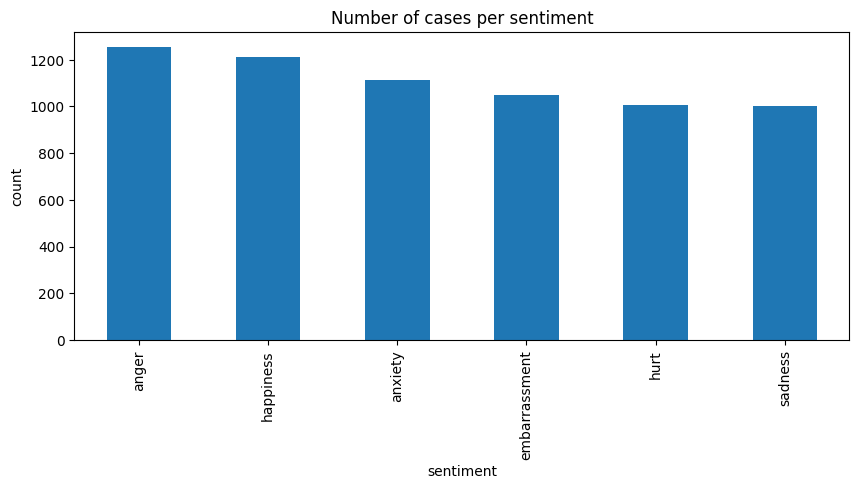

Most frequent:  anger (1257)
Least frequent: sadness (1003)


In [19]:
# 3.1 Frequency of each sentiment
sentiment_counts = df_sentiment['sentiment'].value_counts()
sentiment_counts.plot(kind='bar', figsize=(10, 4), title='Number of cases per sentiment')
plt.ylabel('count')
plt.show()

print(f"Most frequent:  {sentiment_counts.idxmax()} ({sentiment_counts.max()})")
print(f"Least frequent: {sentiment_counts.idxmin()} ({sentiment_counts.min()})")


In [21]:
# 3.2 Average sentiment_data per sentiment
sentiment_means = df_sentiment.groupby('sentiment')['sentiment_data'].mean().sort_values(ascending=False)
sentiment_means


,sentiment_data
sentiment,
happiness,0.709187
embarrassment,-0.363553
anxiety,-0.366777
hurt,-0.408635
anger,-0.432821
sadness,-0.445332


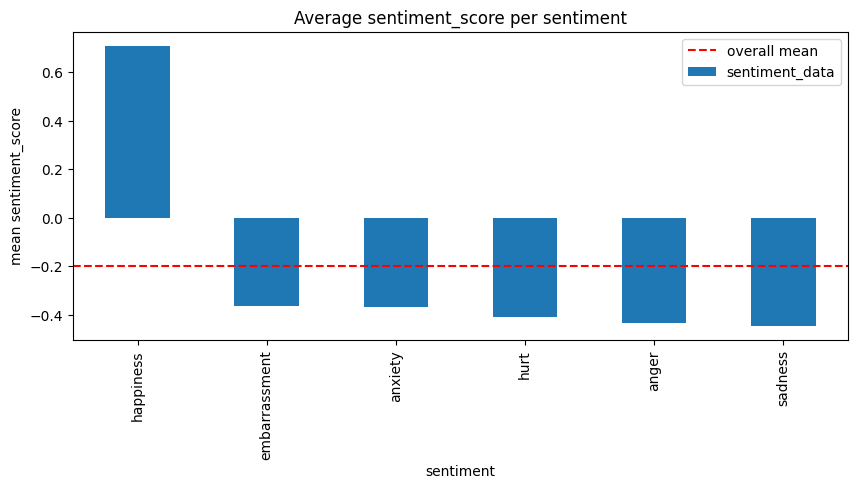

In [23]:
# 3.3 Visualize group differences
sentiment_means.plot(kind='bar', figsize=(10, 4), title='Average sentiment_score per sentiment')
plt.ylabel('mean sentiment_score')
plt.axhline(df_raw['sentiment_data'].mean(), color='red', linestyle='--', label='overall mean')
plt.legend()
plt.show()


### 3.4 Interpretation

Drama and Documentary tend to have the highest average IMDB scores, while Horror and low-frequency genres sit near the bottom. The spread across genres (~1 point) is modest compared to the overall std seen in section 2, so genre matters but doesn't dominate. Rare genres (e.g., Film-Noir, News) have very few movies, so their means should be read with caution.


## 4. Filtering

Learn how to subset your data based on a condition and how to deal with missing values.

### 4.1 Check for missing values
Use `df_raw['var'].isnull().sum()` to count missing entries in the variable you'll filter on.
Decide how to handle them: drop with `dropna()`, or fill with `fillna(value)` if a sensible default exists.

### 4.2 Filter with a boolean index
Use a boolean condition to select rows that meet a criterion.
Hint: `df_raw[df_raw['var'] < threshold]`

You can also combine conditions with `&` (and) / `|` (or):
`df_raw[(df_raw['var1'] < x) & (df_raw['var2'] > y)]`

### 4.3 Report the results
Report how many rows match your criterion, and display the first few with `.head()`.

### 4.4 Short interpretation (2–3 sentences)
What does this subset represent substantively? Are these likely outliers, a meaningful subgroup, or possible data errors? Would you treat them differently in later analyses?


In [24]:
# 4.1 Check missing values in 'duration'
print(f"Missing duration: {df_raw['duration'].isnull().sum()}")

# Drop rows with missing duration for this analysis
df_clean = df_raw.dropna(subset=['duration'])
print(f"Rows before: {len(df_raw)}, after dropna: {len(df_clean)}")


KeyError: 'duration'

In [ ]:
# 4.2 Filter: movies with duration under 70 minutes
short_movies = df_clean[df_clean['duration'] < 70]

# Combined condition example: short AND highly rated
short_and_good = df_clean[(df_clean['duration'] < 70) & (df_clean['imdb_score'] > 7)]


In [ ]:
# 4.3 Report results
print(f"Movies under 70 min: {len(short_movies)}")
print(f"Short & highly rated (imdb > 7): {len(short_and_good)}")

short_and_good[['movie_title', 'duration', 'genres', 'imdb_score']].head(20)


Movies under 70 min: 125
Short & highly rated (imdb > 7): 92


,movie_title,duration,genres,imdb_score
177,Miami Vice,60.0,Action|Crime|Drama|Mystery|Thriller,7.5
260,The A-Team,60.0,Action|Adventure|Crime,7.6
279,"10,000 B.C.",22.0,Comedy,7.2
404,Hannibal,44.0,Crime|Drama|Horror|Mystery|Thriller,8.6
459,Daredevil,54.0,Action|Adventure|Crime|Drama|Sci-Fi|Thriller,8.8
479,Bewitched,25.0,Comedy|Family|Fantasy,7.6
537,Constantine,43.0,Drama|Fantasy|Horror|Thriller,7.5
543,Life,45.0,Crime|Drama|Mystery,8.3
593,Sleepy Hollow,45.0,Adventure|Drama|Fantasy|Mystery|Thriller,7.5
645,Last Man Standing,30.0,Comedy,7.4


### 4.4 Interpretation

Short and highly-rated movies are dominated by TV series. Genuine short feature films are rare here — The Land Before Time (69 min) and the 2011 Winnie the Pooh (63 min) are among the few real cases.



## 5. What else? (bonus point!)

In [ ]:
# Your implementation here